# Predicting future values
here time is split into trainin and testing. Prediction is done and evaluated. 
we will predict 3 month revenue for a customer using RFM + behaviour

In [80]:
import pandas as pd

In [81]:
rfm = pd.read_csv("data/rfm_features.csv")
df = pd.read_csv("data/cleaned_data.csv")

In [82]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [83]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [84]:
cuttof = df["InvoiceDate"].max() - pd.DateOffset(months=3)

In [85]:
cuttof

Timestamp('2011-09-09 12:50:00')

In [86]:
train_df = df[df["InvoiceDate"] <= cuttof]
future_df = df[df["InvoiceDate"] > cuttof]

how we are going to make the dataset:  
from the train data -> extracting features (x)  
from the future data (test data) -> taking target(y)  

by this we can input to the model

# building rfm on train data

cuttoff = last date of training window  
Everything after that is “future”  
so taking the data just before the cuttoff date (why - because, we want to predict the future right, if not done, first day recency will be 0) -> we are adding another day to cuttoffday

In [87]:
snapshot_train_data = cuttof + pd.Timedelta(days=1)

In [88]:
snapshot_train_data

Timestamp('2011-09-10 12:50:00')

In [89]:
# diving the trainig data to recency, frequency, monetory

In [90]:
rfm_train = train_df.groupby("CustomerID").agg({
    "InvoiceDate" : lambda x: (snapshot_train_data - x.max()).days, # this is the recency
    "InvoiceNo": "nunique", # frequency
    "Revenue" : "sum" #monetory
    
})

In [91]:
rfm_train.columns = ["Recency", "Frequency", "Monetary"]

In [92]:
rfm_train.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,235,1,77183.60
12347.0,39,5,2790.86
12348.0,158,3,1487.24
12350.0,219,1,334.40
12352.0,171,5,1561.81


In [93]:
# target column of future data

In [94]:
future_revenue = future_df.groupby("CustomerID")["Revenue"].sum().reset_index()

In [95]:
future_revenue.head(2)

,CustomerID,Revenue
0,12347.0,1519.14
1,12348.0,310.00


In [96]:
future_revenue.columns  =["CustomerID", "clv"]

In [97]:
data_merged = rfm_train.merge(future_revenue, on= "CustomerID", how = "left")
data_merged.head()

,CustomerID,Recency,Frequency,Monetary,clv
0,12346.0,235,1,77183.60,NaN
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,NaN
4,12352.0,171,5,1561.81,944.23


In [98]:
#adding extra features (from here)

extra = df.groupby("CustomerID").agg({
    "Revenue": ["mean", "std"],
    "InvoiceNo": "nunique",
    "InvoiceDate": ["min", "max"]
})

In [99]:
extra.columns = ["AvgRevenue", "StdRevenue", "Frequency2", "FirstPurchase", "LastPurchase"]

In [100]:
snapshot_date_train = cuttof + pd.Timedelta(days=1)
extra["CustomerAgeDays"] = (snapshot_date_train - extra["FirstPurchase"]).dt.days

In [101]:
data_merged_extra = data_merged.merge(extra.reset_index(), on="CustomerID", how="left")

here containing Nan values - people who do not purchased with in last 3 months is not in the list of future df. so after merging they are not in the list

In [102]:
print(data_merged_extra.isna().sum())
print(data_merged_extra.shape)

CustomerID            0
Recency               0
Frequency             0
Monetary              0
clv                1445
AvgRevenue            0
StdRevenue           55
Frequency2            0
FirstPurchase         0
LastPurchase          0
CustomerAgeDays       0
dtype: int64
(3365, 11)


In [103]:
# data_merged_extra.dropna().shape

In [104]:
# data_merged["clv"] = data_merged["clv"].fillna(0)
# data_merged_extra = data_merged_extra.fillna(0)
data_merged_extra[["AvgRevenue", "StdRevenue", "CustomerAgeDays","clv"]] = data_merged_extra[["AvgRevenue", "StdRevenue", "CustomerAgeDays","clv"]].fillna(0)

In [105]:
data_merged_extra.head(2)

,CustomerID,Recency,Frequency,Monetary,clv,AvgRevenue,StdRevenue,Frequency2,FirstPurchase,LastPurchase,CustomerAgeDays
0,12346.0,235,1,77183.60,0.00,77183.600000,0.000000,1,2011-01-18 10:01:00,2011-01-18 10:01:00,235
1,12347.0,39,5,2790.86,1519.14,23.681319,23.289902,7,2010-12-07 14:57:00,2011-12-07 15:52:00,276


# training clv model

In [106]:
# from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np
from xgboost import XGBRegressor

In [145]:
y_raw = data_merged_extra["clv"]
y = np.log1p(y_raw)

In [146]:
# x = data_merged_extra.drop(columns=["clv","CustomerID"])
# y = data_merged["clv"]
x = data_merged_extra[["Recency", "Frequency", "Monetary", "AvgRevenue", "StdRevenue", "CustomerAgeDays"]]

In [147]:
x.head(2)


,Recency,Frequency,Monetary,AvgRevenue,StdRevenue,CustomerAgeDays
0,235,1,77183.60,77183.600000,0.000000,235
1,39,5,2790.86,23.681319,23.289902,276


In [148]:
print(x.head(2),end="\n\n")
print(y.head(2))

   Recency  Frequency  Monetary    AvgRevenue  StdRevenue  CustomerAgeDays
0      235          1  77183.60  77183.600000    0.000000              235
1       39          5   2790.86     23.681319   23.289902              276

0    0.000000
1    7.326558
Name: clv, dtype: float64


In [149]:
x_train,x_test, y_train, y_test = train_test_split(x,y, random_state=42)

In [150]:
# model = RandomForestRegressor(n_estimators=100, random_state=42)
model = XGBRegressor(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [151]:
model.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [152]:
y_pred_log = model.predict(x_test)


In [153]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [154]:
r2score = r2_score(y_pred, y_test)
rmse = root_mean_squared_error(y_pred,y_test)

In [155]:
print(f"r2score {r2score:.4f}")
print("rmse ",rmse)

r2score -0.0569
rmse  1459.2737408245073


In [156]:
from scipy.stats import spearmanr
spearmanr(y_test, y_pred_log).correlation


np.float64(0.5309038087511165)

In [158]:
# this is positive, so we can use the modelfor predcition

# feature importance

In [ ]:
# fi = model.feature_importances_
# fi
# array([0.0271568 , 0.02502621, 0.07237632, 0.87544068])

In [ ]:
fi = pd.Series(model.feature_importances_, index = x.columns)

In [ ]:
import matplotlib.pyplot as plt

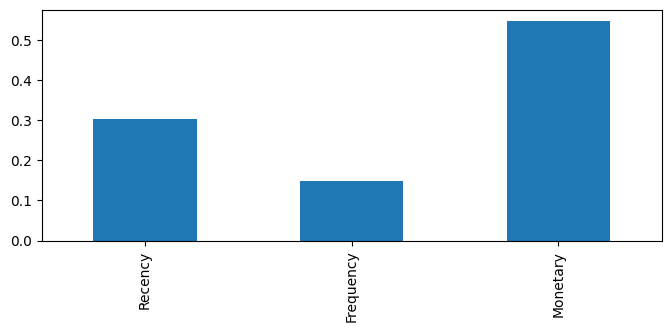

In [ ]:
plt.figure(figsize=(8,3))
fi.plot(kind="bar")
plt.show()

In [ ]:
import joblib

In [ ]:
import os
os.makedirs("models", exist_ok=True)

In [ ]:
joblib.dump(model,"models/clv_model.joblib")

['models/clv_model.joblib']

In [ ]:
# type(model)

In [ ]:
# model.predict([[326,1,77183.6]])